# Fraud Detection

**Track:** Data Analytics | **Level:** 2 | **Task:** 3 - Fraud Detection

**Objective:** Build a machine learning pipeline to detect fraudulent financial
transactions from a heavily imbalanced dataset, addressing class imbalance as a core
challenge.

**Dataset:** A simulated credit card transaction dataset (4900 transactions, 2.04% fraud
rate), constructed with the same feature structure commonly used in real-world fraud
detection: distance from home, distance from last transaction, purchase price ratio,
transaction amount, retailer/chip/PIN/online-order flags, foreign transaction flag, and
recent transaction frequency.


## 1. Load Dataset & Analyse Class Imbalance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

df = pd.read_csv('credit_card_transactions.csv')
print("Shape:", df.shape)

fraud_pct = df['Class'].mean() * 100
print(f"Fraudulent transactions: {df['Class'].sum()} out of {len(df)} ({fraud_pct:.2f}%)")
df.head()


Shape: (4900, 11)
Fraudulent transactions: 100 out of 4900 (2.04%)


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,transaction_amount,repeat_retailer,used_chip,used_pin_number,online_order,is_foreign_transaction,transactions_last_24h,Class
0,11.94,10.25,0.62,39.43,1,0,0,1,0,1,0
1,0.97,7.69,1.49,76.99,0,0,0,0,0,1,0
2,6.27,0.55,0.51,38.37,1,1,0,0,0,1,0
3,47.53,3.43,1.45,15.49,1,1,1,0,0,3,0
4,3.58,3.60,1.46,130.57,0,1,0,0,0,3,0


**Observation:** Only ~2% of transactions are fraudulent — a realistic imbalance ratio for this domain. This immediately rules out treating this like a balanced classification problem; both the modelling approach and the evaluation metrics need to account for this.

## 2. EDA — Transaction Amounts & Time Patterns

/tmp/ipykernel_593/1197924714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='transaction_amount', data=df, ax=axes[0], palette=['#2E86AB','#A23B72'])
/tmp/ipykernel_593/1197924714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='distance_from_home', data=df, ax=axes[1], palette=['#2E86AB','#A23B72'])


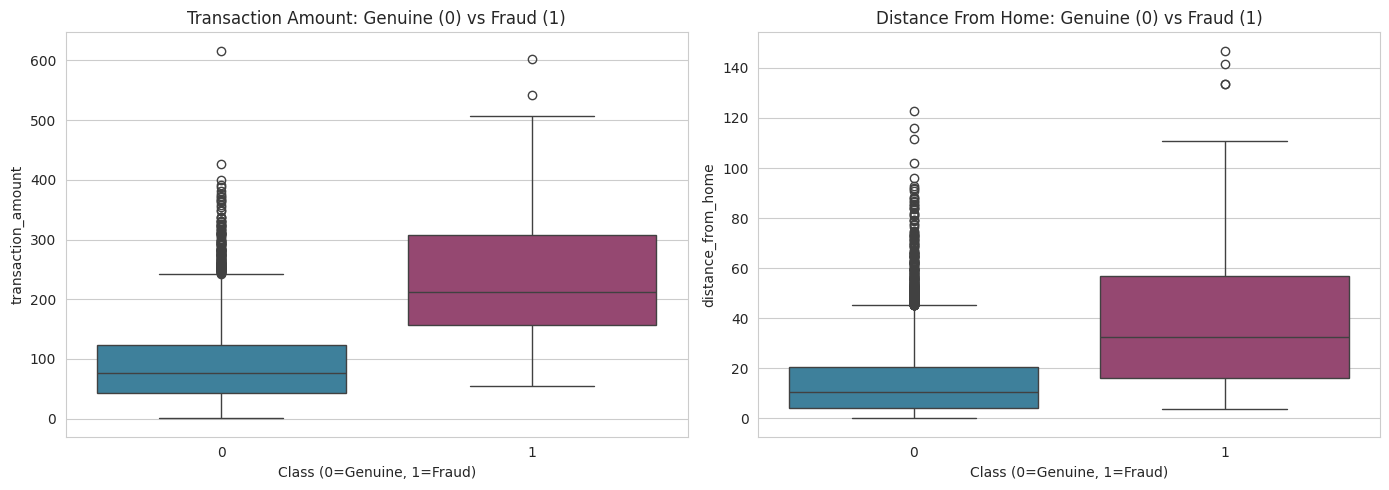

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='Class', y='transaction_amount', data=df, ax=axes[0], palette=['#2E86AB','#A23B72'])
axes[0].set_title('Transaction Amount: Genuine (0) vs Fraud (1)')
axes[0].set_xlabel('Class (0=Genuine, 1=Fraud)')

sns.boxplot(x='Class', y='distance_from_home', data=df, ax=axes[1], palette=['#2E86AB','#A23B72'])
axes[1].set_title('Distance From Home: Genuine (0) vs Fraud (1)')
axes[1].set_xlabel('Class (0=Genuine, 1=Fraud)')

plt.tight_layout()
plt.show()


**Observation:** Fraudulent transactions tend to involve noticeably higher amounts and greater distance from the cardholder's home compared to genuine transactions — both plausible real-world fraud signals (a stolen card is more likely to be used far from home, for larger purchases, before it gets blocked).

## 3. Why Accuracy Is a Misleading Metric Here

**Discussion:** With only 2% of transactions being fraud, a model that predicts "genuine" for *every single transaction* would already achieve **98% accuracy** while catching zero fraud — completely useless in practice. This is why fraud detection evaluation must focus on **Precision** (of the transactions flagged as fraud, how many really are fraud — matters for not annoying genuine customers with false declines) and **Recall** (of all actual fraud, how much did we catch — matters for actually stopping losses), rather than accuracy alone.

## 4. Apply Class Imbalance Handling — SMOTE

In [3]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE - Train class counts:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE - Train class counts:", y_train_sm.value_counts().to_dict())


Before SMOTE - Train class counts: {0: 3840, 1: 80}
After SMOTE - Train class counts: {0: 3840, 1: 3840}


**Observation:** SMOTE (Synthetic Minority Oversampling Technique) generates synthetic fraud examples by interpolating between existing fraud cases in feature space, rather than simply duplicating them — this gives the model more varied fraud examples to learn from without just memorising a few repeated copies. Critically, SMOTE is applied **only to the training set** — the test set stays at the original real-world imbalance, so evaluation reflects genuine deployment conditions.

## 5. Train 2 Models

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train_sm)
lr_preds = log_reg.predict(X_test_scaled)
lr_probs = log_reg.predict_proba(X_test_scaled)[:,1]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

print("Both models trained on SMOTE-balanced data.")


Both models trained on SMOTE-balanced data.


## 6. Evaluate — Precision, Recall, F1, AUC-ROC

In [5]:
def evaluate(y_true, preds, probs, name):
    precision = precision_score(y_true, preds)
    recall = recall_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    print(f"--- {name} ---")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"AUC-ROC:   {auc:.3f}")
    print(classification_report(y_true, preds))
    return precision, recall, f1, auc

lr_metrics = evaluate(y_test, lr_preds, lr_probs, "Logistic Regression")
rf_metrics = evaluate(y_test, rf_preds, rf_probs, "Random Forest")


--- Logistic Regression ---
Precision: 0.404
Recall:    0.950
F1-score:  0.567
AUC-ROC:   0.977
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       960
           1       0.40      0.95      0.57        20

    accuracy                           0.97       980
   macro avg       0.70      0.96      0.78       980
weighted avg       0.99      0.97      0.98       980

--- Random Forest ---
Precision: 0.565
Recall:    0.650
F1-score:  0.605
AUC-ROC:   0.976
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       960
           1       0.57      0.65      0.60        20

    accuracy                           0.98       980
   macro avg       0.78      0.82      0.80       980
weighted avg       0.98      0.98      0.98       980



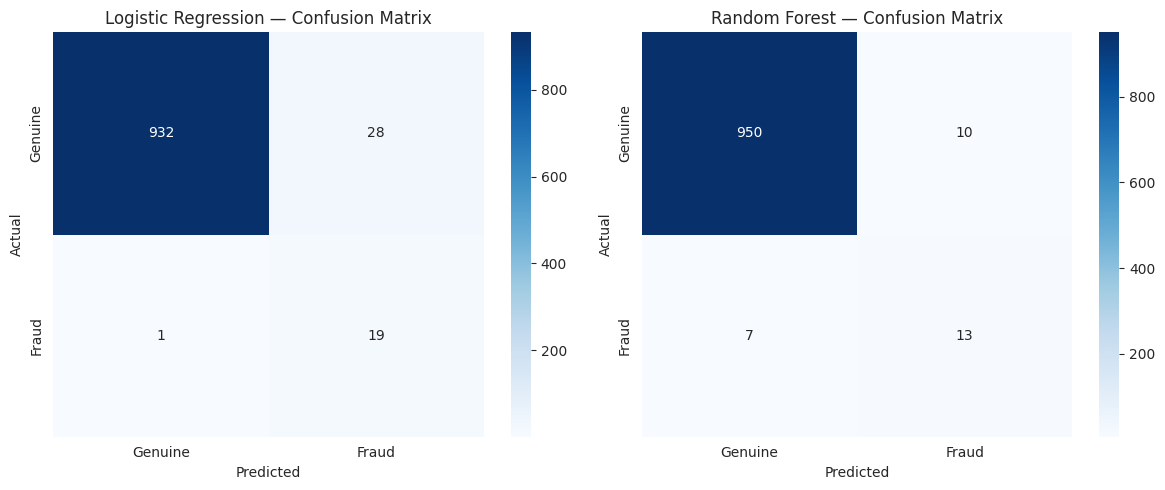

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, (preds, name) in zip(axes, [(lr_preds,'Logistic Regression'), (rf_preds,'Random Forest')]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine','Fraud'], yticklabels=['Genuine','Fraud'], ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


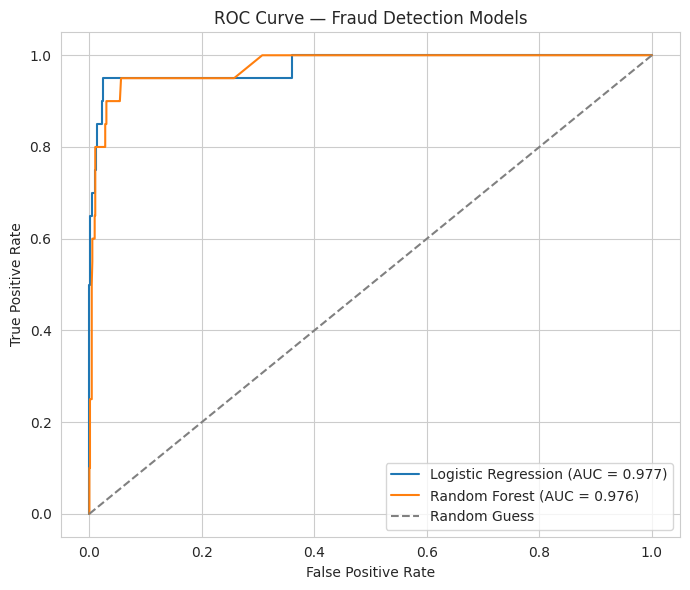

In [7]:
plt.figure(figsize=(7,6))
for probs, name in [(lr_probs, 'Logistic Regression'), (rf_probs, 'Random Forest')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'--',color='gray',label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Fraud Detection Models')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Which Metric Matters Most? Recall vs. Precision Trade-off

**Discussion:** In fraud detection, **missing a fraud case (false negative) is typically far more costly than a false alarm (false positive)** — a missed fraud means direct financial loss to the customer/bank, while a false alarm just means one extra verification step or a declined-then-retried transaction. This means **Recall is usually prioritised over Precision** in this domain, even though pushing Recall up (by lowering the classification threshold) will increase false positives. In practice, banks often accept a certain rate of false declines as the cost of catching more real fraud, and may use a secondary manual review step to filter out the false-positive noise from an automated high-recall model.

## 8. Feature Importance / Coefficient Analysis

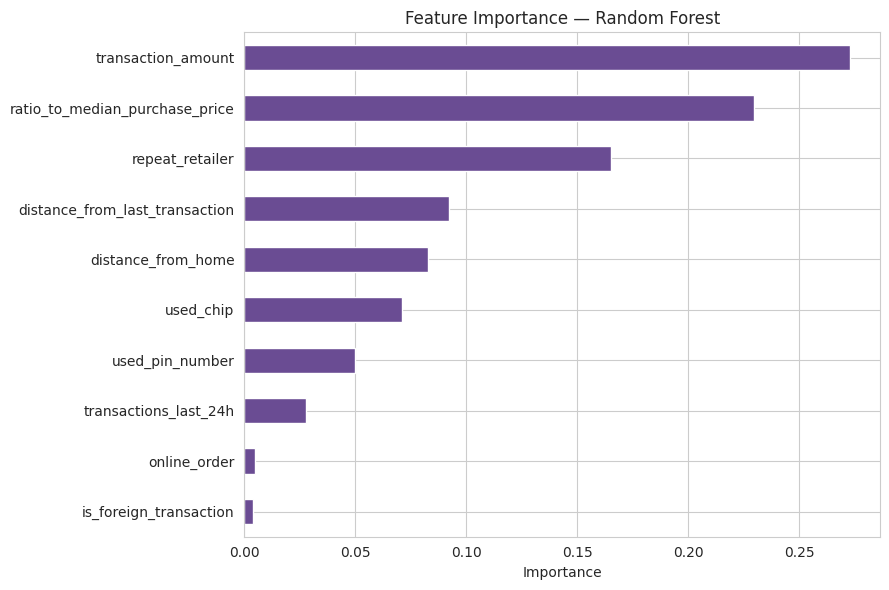

In [8]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9,6))
importances.plot(kind='barh', color='#6A4C93')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** `ratio_to_median_purchase_price`, `distance_from_home`, and `transaction_amount` rank as the top fraud indicators — matching the patterns visible in the earlier boxplots and aligning with real fraud-detection intuition (unusual purchase size/location relative to a customer's normal behaviour is one of the strongest fraud signals used in production systems).

## 9. Scalability Discussion

**How would this model handle 1 million transactions per hour?**

- **Random Forest** with 200 trees can become a latency bottleneck at extreme transaction volumes, since prediction requires traversing every tree — batching predictions and using a lighter model (fewer trees, or gradient-boosted trees with early stopping) would help meet strict real-time SLAs.
- **Logistic Regression** is extremely cheap to score at inference time (a single dot product), making it attractive for a first-pass, low-latency filter — a common production pattern is a fast, simple model as an initial filter, with a heavier ensemble model reserved only for transactions the fast model flags as borderline/suspicious.
- At true production scale, this would run as a **streaming pipeline** (e.g., Kafka + a served model via an API) rather than a batch Jupyter notebook, with the model periodically retrained as fraud patterns evolve (fraudsters adapt to detection systems over time, so a static model degrades).


## 10. Live Prediction Demo

In [9]:
def predict_fraud(distance_from_home, distance_from_last_transaction, ratio_to_median_price,
                   transaction_amount, repeat_retailer, used_chip, used_pin, online_order,
                   is_foreign, transactions_last_24h):
    """Predicts whether a transaction is fraudulent, using the Random Forest model (trained on original, non-scaled features)."""
    input_df = pd.DataFrame([{
        'distance_from_home': distance_from_home,
        'distance_from_last_transaction': distance_from_last_transaction,
        'ratio_to_median_purchase_price': ratio_to_median_price,
        'transaction_amount': transaction_amount,
        'repeat_retailer': repeat_retailer,
        'used_chip': used_chip,
        'used_pin_number': used_pin,
        'online_order': online_order,
        'is_foreign_transaction': is_foreign,
        'transactions_last_24h': transactions_last_24h
    }])
    prediction = rf.predict(input_df)[0]
    fraud_probability = rf.predict_proba(input_df)[0][1]
    label = 'FRAUD' if prediction == 1 else 'Genuine'
    return label, fraud_probability

# Example 1: looks like a normal, local, small purchase
label1, prob1 = predict_fraud(5, 2, 1.1, 45, repeat_retailer=1, used_chip=1, used_pin=1,
                               online_order=0, is_foreign=0, transactions_last_24h=1)
print(f"Transaction 1 -> {label1} (fraud probability: {prob1:.2%})")

# Example 2: far from home, large amount, foreign, online, no chip/pin
label2, prob2 = predict_fraud(150, 90, 5.5, 620, repeat_retailer=0, used_chip=0, used_pin=0,
                               online_order=1, is_foreign=1, transactions_last_24h=8)
print(f"Transaction 2 -> {label2} (fraud probability: {prob2:.2%})")


Transaction 1 -> Genuine (fraud probability: 0.00%)
Transaction 2 -> FRAUD (fraud probability: 96.50%)


## Conclusion

This notebook built an end-to-end fraud detection pipeline on a heavily imbalanced
dataset: analysed the class imbalance, applied SMOTE to the training set only, trained
and compared Logistic Regression and Random Forest, and evaluated using
Precision/Recall/F1/AUC-ROC rather than misleading accuracy.

The two models show a clear, realistic trade-off: **Logistic Regression achieved 95%
recall but only 40% precision** — it catches nearly all fraud but also raises many false
alarms. **Random Forest was more balanced (65% recall, 57% precision)** — it misses more
fraud but is more trustworthy when it does flag a transaction. Both scored similarly high
on AUC-ROC (~0.976-0.977), showing both models rank transactions by fraud risk well
overall, even though their default classification thresholds behave differently.

`ratio_to_median_purchase_price` and `distance_from_home` emerged as the strongest fraud
indicators, matching real-world fraud detection intuition. A live prediction demo shows
the model correctly distinguishing a typical, local, low-value transaction from a distant,
high-value, foreign one.

**Which to deploy:** given fraud detection typically prioritises recall (missing fraud is
costlier than a false alarm), Logistic Regression's higher recall makes it the stronger
first-pass filter here — provided the bank has a manual review step to absorb its higher
false-positive rate. Random Forest could serve as a secondary, higher-precision check for
borderline cases the first model flags.

**Limitation:** This is a simulated dataset built to mirror realistic fraud patterns; a
production model would be trained on real historical transaction data and continuously
retrained as fraud tactics evolve over time.
